<a href="https://colab.research.google.com/github/mathuraryan036-collab/DL-GOOGLE-COLAB/blob/main/Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# # Imports libraries and generates a random 2D dataset with 100 samples for binary classification.
from sklearn.datasets import make_classification
import numpy as np
x, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [3]:
# Imports the matplotlib library to visualize the dataset and the decision boundary.
import matplotlib.pyplot as plt

In [6]:
# Displays the feature coordinates (x) of the generated dataset.
x

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [7]:
# Displays the target labels (0 or 1) for each data point in the dataset.
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

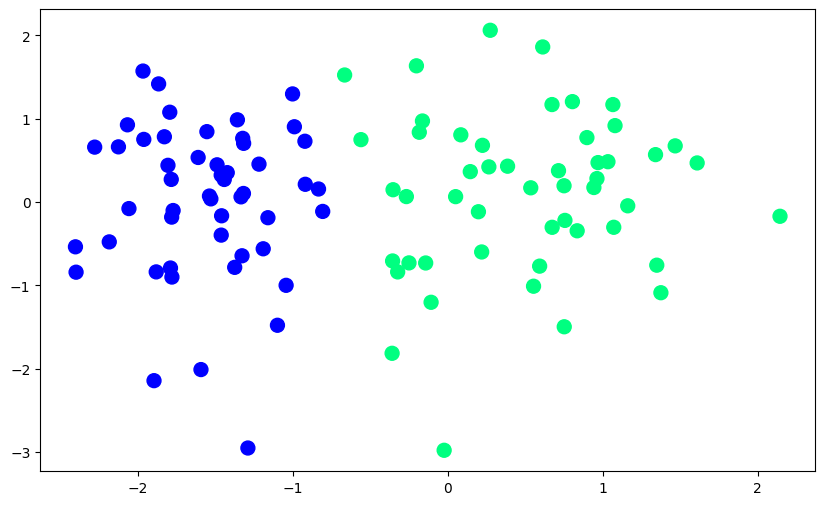

In [4]:
# Creates a scatter plot of the dataset, coloring the points based on their class labels.
plt.figure(figsize=(10,6))
plt.scatter(x[:,0], x[:,1], c=y, cmap='winter', s=100)

In [19]:
# Defines a custom perceptron algorithm that iteratively updates weights based on prediction errors.
# It trains for 1000 epochs and returns the final intercept and coefficients.def perceptron(x, y):

x = np.insert(x, 0, 1, axis = 1)
weights = np.ones(x.shape[1])
lr = 0.1

for i in range(1000):
  j = np.random.randint(0, 100)
  y_hat = step(np.dot(x[j], weights))
  weights = weights + lr*(y[j] - y_hat)*x[j]

return weights[0], weights[1:]

In [20]:
# Defines the step activation function, outputting 1 if the input is positive and 0 otherwise.
def step(z):
  return 1 if z > 0 else 0

In [21]:
# Runs the custom perceptron algorithm on the data to find the best intercept and coefficients.
intercept_,coef_ = perceptron(x, y)

In [22]:
# Prints the learned weights (coefficients) and bias (intercept) of the model.
print(coef_)
print(intercept_)

[1.3246835  0.00690465]
1.0


In [23]:
# Calculates the slope (m) and y-intercept (b) of the decision boundary line from the perceptron weights.
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [24]:
# Generates x and y coordinates to draw the decision boundary line based on the calculated slope and intercept.
x_input = np.linspace(-3, 3, 100)
y_input =  m*x_input + b

(-3.0, 2.0)

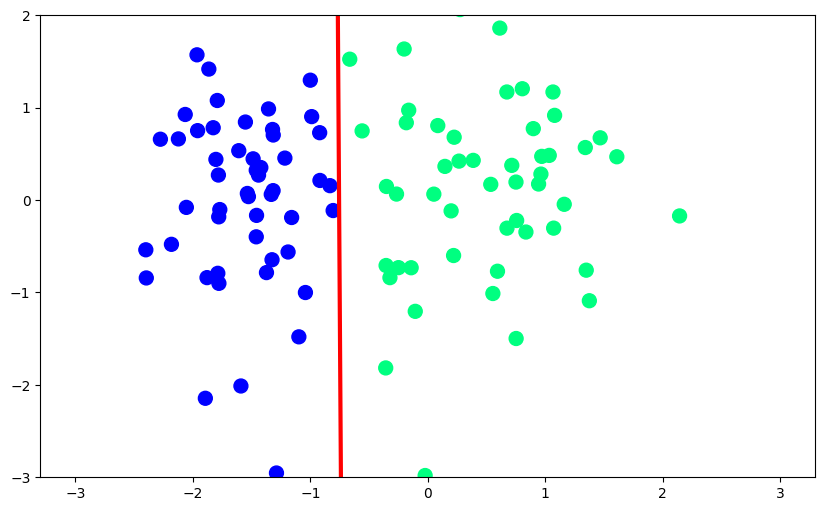

In [25]:
# Plots the generated dataset alongside the learned decision boundary (red line) to visualize the classification.
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 100)
plt.ylim(-3, 2)

In [26]:
# Modifies the perceptron function to record the slope and intercept at each iteration to track learning over time.
def perceptron(x, y):

  m = []
  b = []

  x = np.insert(x, 0, 1, axis = 1)
  weights = np.ones(x.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(x[j], weights))
    weights = weights + lr*(y[j] - y_hat)*x[j]

    m.append(-weights[1]/weights[2])
    b.append(-weights[0]/weights[2])

  return m, b

In [28]:
# Runs the modified perceptron to get the history of slopes and intercepts for animation.
m, b = perceptron(x, y)

In [29]:
# Imports animation modules from matplotlib to create an animated plot of the learning process.
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [37]:
# Sets up the plot and defines an update function to animate how the decision boundary line shifts during training.
fig, ax = plt.subplots(figsize = (9, 5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] + b[0]
ax.scatter(x[:,0], x[:,1], c = y, cmap = 'winter', s = 100)
line = ax.plot(x_i, x_i*m[0] + b[0], 'r-', linewidth = 2)[0]
plt.ylim(-3, 3)

def update(i):
  label  = 'epoch {0}'.format(i + 1)
  line.set_ydata(x_i*m[i] + b[i])
  ax.set_xlabel(label)

anim = FuncAnimation(fig, update, repeat = True, frames = 200, interval = 100)

<IPython.core.display.Javascript object>

In [38]:
# Configures the video writer and saves the training animation as a GIF file.
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
anim.save('perceptron_animation.gif', writer=writer)

Here's the animation of the perceptron learning its decision boundary:

In [40]:
# Loads and displays the saved GIF animation directly within the notebook.
from IPython.display import Image
Image(url='perceptron_animation.gif')